<br> </br>
<font color='darkred' size = 7.5> <center>  <b> Quantitative strategies on high-frequency data </b> </center> </font>
<font color='darkred' size = 5> <center>  6. Assessing strategy performance </center> </font>
<br>
<font size = 5> <center> prof. Piotr Wójcik </center> </font>
<br> 
<font size = 5> <center>  academic year 2025/2026 </center> </font>

In [ ]:
# pip install quantstats

In [4]:
# lets load the needed libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import quantstats as qs
import warnings
warnings.simplefilter(action="ignore", category=UserWarning)  # ignoruje wszystkie ostrzeżenia typu UserWarning

# Exercises 6

Perform similar analyses for the assets selected and analyzed in previous labs.

In [5]:
# place for solution to Exercise 5.1
file_path = "/Users/shah/CODE_BOOK_3/code_document/HFT-WNE/05/output/dataUSA_GM_GE_05.pkl"


dataUSA_GM_GE = pd.read_pickle(file_path)

dataUSA_GM_GE.iloc[10:12, ]

,close_GM,close_GE,close_GM_EMA10,med_short,med_long,vol_mad10,close_GM_SMA20,position1_mom,position1_mr,pnl_gross1_mom,...,ntrans2,pnl_net2a,pnl_net2b,position3a_vb,close_GM_VB_lower,close_GM_VB_upper,position_3b_vb,pnl_gross3a_vb,ntrans3,pnl_net3a_vb
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-02 09:41:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0.0,...,0.0,0.0,0.0,-0.0,NaN,NaN,0.0,0.0,0.0,0.0
2025-01-02 09:42:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0.0,...,0.0,0.0,0.0,-0.0,NaN,NaN,0.0,0.0,0.0,0.0


In [ ]:
##### Changing column names for consistency. "pnl_gross_2a" -> "pnl_gross2a"
dataUSA_GM_GE.rename(columns={'pnl_gross_2a': 'pnl_gross2a'}, inplace=True)
dataUSA_GM_GE.rename(columns={'pnl_gross_2b': 'pnl_gross2b'}, inplace=True)


In [7]:
dataUSA_GM_GE.filter(like = "pnl").head(1)

,pnl_gross1_mom,pnl_gross1_mr,pnl_net1_mom,pnl_net1_mr,pnl_gross2a,pnl_gross2b,pnl_net2a,pnl_net2b,pnl_gross3a_vb,pnl_net3a_vb
timestamp,,,,,,,,,,
2025-01-02 09:31:00,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN


# Exercise 6.1

* Load previously saved data with positions and PnL 
* Calculate the gross and net SR for a strategy based on a single moving average (SMA or EMA)
* Calculate and plot the maximum drawdown on the chart

In [18]:
# place for solution to Exercise 6.1
# Lets first define the SR function
def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x)/np.nanstd(x)

# Since our strategy works between 9:45 and 3:40 . Enter 15 mins later . Exit 20 mins early. 
TradingMinsInDay = 6.5 * 60 - 15 - 20
print(f"Gross SR of momentum strategy based on EMA10 {mySR(dataUSA_GM_GE['pnl_gross1_mom'], scale = TradingMinsInDay * 252)}")
print(f"Net SR of momentum strategy based on (EMA10) {mySR(dataUSA_GM_GE['pnl_net1_mom'], scale = TradingMinsInDay * 252)}")


Gross SR of momentum strategy based on EMA10 -5.227198678869097
Net SR of momentum strategy based on (EMA10) -142.83531249212362


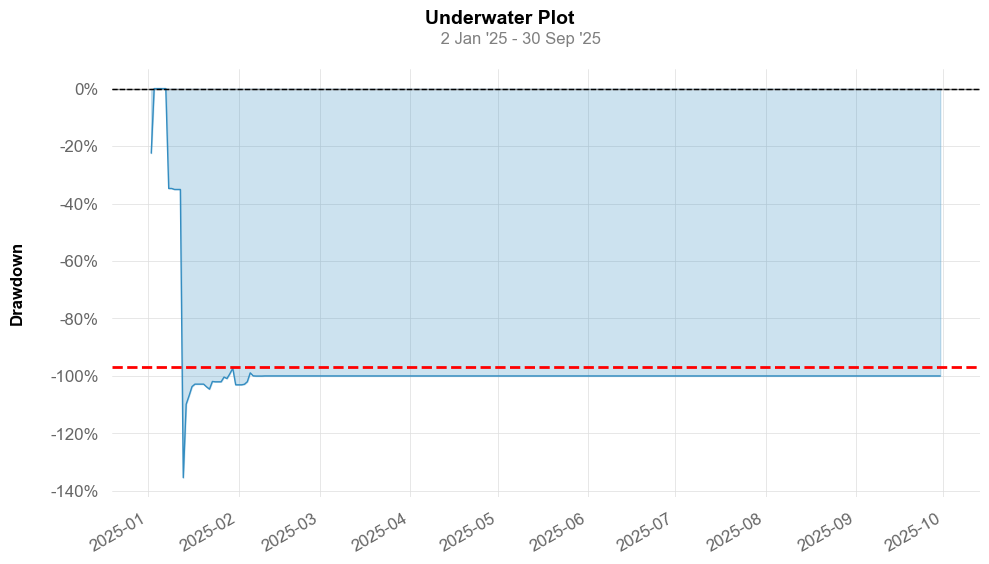

In [35]:
# For the plot, lets calculate the daily summary of the position
summary_GM_daily = (
    dataUSA_GM_GE.resample('D')
    .agg({col: 'sum' for col in dataUSA_GM_GE.columns if col.startswith('pnl_') or col.startswith('ntrans')})
)
# Max drawdown plot of strategy 1 . Momentum variant.
returns_strategy = summary_GM_daily['pnl_gross1_mom'].dropna()

qs.plots.drawdown(returns_strategy, figsize=(10, 6))

In [ ]:
# Let's add the profit/loss columns in percentage terms
# NOTE from HFD05 strategy 1 was defined as 
# : cond1_mom_long = dataUSA_GM_GE['close_GM'].shift(1) > dataUSA_GM_GE['close_GM_EMA10'].shift(1)

# strategy 1a : Momentum
dataUSA_GM_GE['pnl_gross1_mom_pct'] = (dataUSA_GM_GE['pnl_gross1_mom'] / dataUSA_GM_GE['close_GM'].shift(1))
dataUSA_GM_GE['pnl_net1_mom_pct'] = (dataUSA_GM_GE['pnl_net1_mom'] / dataUSA_GM_GE['close_GM'].shift(1))
# strategy 1b : Mean_reverting
dataUSA_GM_GE['pnl_gross1_mr_pct'] = (dataUSA_GM_GE['pnl_gross1_mr'] / dataUSA_GM_GE['close_GM'].shift(1))
dataUSA_GM_GE['pnl_net1_mr_pct'] = (dataUSA_GM_GE['pnl_net1_mr'] /dataUSA_GM_GE['close_GM'].shift(1))

# strategy 2a : Momentum
dataUSA_GM_GE['pnl_gross2a_mom_pct'] = (dataUSA_GM_GE['pnl_gross2a'] / dataUSA_GM_GE['close_GM'].shift(1))
dataUSA_GM_GE['pnl_net2a_mr_pct'] = (dataUSA_GM_GE['pnl_net2a'] / dataUSA_GM_GE['close_GM'].shift(1))
# strategy 2b : Mean_reverting
dataUSA_GM_GE['pnl_gross2b_mr_pct'] = (dataUSA_GM_GE['pnl_gross2b'] / dataUSA_GM_GE['close_GM'].shift(1))
dataUSA_GM_GE['pnl_net2b_mr_pct'] = (dataUSA_GM_GE['pnl_net2b'] / dataUSA_GM_GE['close_GM'].shift(1))
# strategy 3a : Momentum
dataUSA_GM_GE['pnl_gross3a_mom_pct'] = (dataUSA_GM_GE['pnl_gross3a_vb'] / dataUSA_GM_GE['close_GM'].shift(1))
dataUSA_GM_GE['pnl_net3a_mom_pct'] = (dataUSA_GM_GE['pnl_net3a_vb'] / dataUSA_GM_GE['close_GM'].shift(1))

### Intuition behind the sharpee for gross vs net pnl:
For each chunk of risk the strategy takes, you typically earn money before costs and loose money after paying costs

# Exercise 6.2

* Calculate the gross and net SR for a strategy based on two moving medians
* Calculate and plot the maximum drawdown on the chart


In [30]:
# Converting to percetnage for testing SR computation difference
# strategy 2a : Momentum
dataUSA_GM_GE['pnl_gross2a_pct'] = (dataUSA_GM_GE['pnl_gross2a'] / dataUSA_GM_GE['close_GM'].shift(1))
dataUSA_GM_GE['pnl_net2a_pct'] = (dataUSA_GM_GE['pnl_net2a'] / dataUSA_GM_GE['close_GM'].shift(1))
# strategy 2b : Mean_reverting
dataUSA_GM_GE['pnl_gross2b_pct'] = (dataUSA_GM_GE['pnl_gross2b'] / dataUSA_GM_GE['close_GM'].shift(1))
dataUSA_GM_GE['pnl_net2b_pct'] = (dataUSA_GM_GE['pnl_net2b'] / dataUSA_GM_GE['close_GM'].shift(1))

In [33]:
TradingMinsInDay = 6.5 * 60 - 15 - 20
print(f"Gross SR of mean_reverting strategy based on 2 moving medians {mySR(dataUSA_GM_GE['pnl_gross2b_pct'], scale = TradingMinsInDay * 252)}")
print(f"Net SR of mean_reverting strategy based on 2 moving medians {mySR(dataUSA_GM_GE['pnl_net2b_pct'], scale = TradingMinsInDay * 252)}")

Gross SR of mean_reverting strategy based on 2 moving medians 2.967044826075491
Net SR of mean_reverting strategy based on 2 moving medians -31.504749505323044


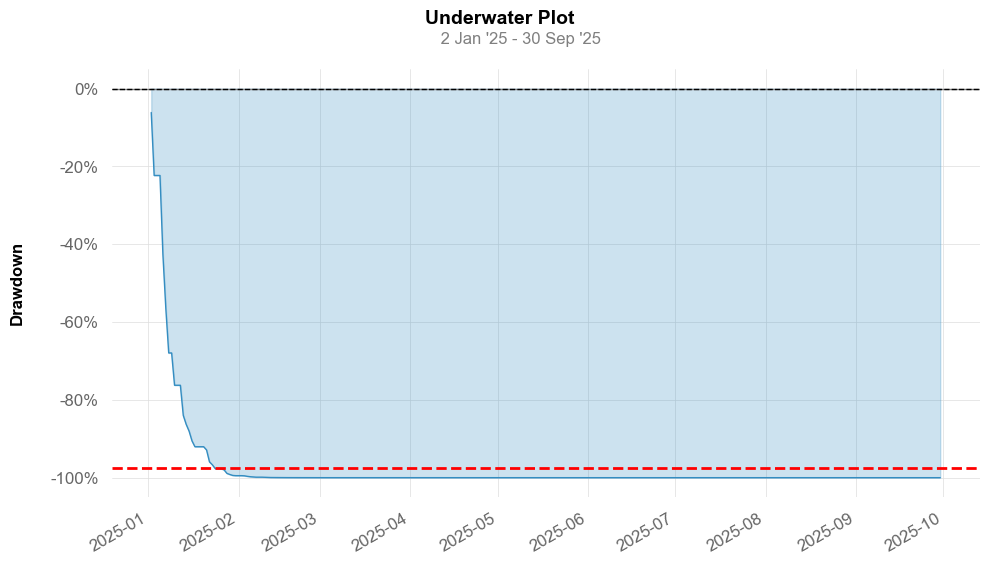

In [38]:
# Max drawdown plot of strategy 2b
summary_GM_daily = (
    dataUSA_GM_GE.resample('D')
    .agg({col: 'sum' for col in dataUSA_GM_GE.columns if col.startswith('pnl_') or col.startswith('ntrans')})
)
returns_strategy = summary_GM_daily['pnl_net2b_pct'].dropna()

qs.plots.drawdown(returns_strategy, figsize=(10, 6))

# Exercise 6.3

* Calculate the gross and net SR for a strategy based on the volatility breakout model
* Calculate and plot the maximum drawdown on the chart

In [39]:
# strategy 3a : Momentum
dataUSA_GM_GE['pnl_gross3a_mom_pct'] = (dataUSA_GM_GE['pnl_gross3a_vb'] / dataUSA_GM_GE['close_GM'].shift(1))
dataUSA_GM_GE['pnl_net3a_mom_pct'] = (dataUSA_GM_GE['pnl_net3a_vb'] / dataUSA_GM_GE['close_GM'].shift(1))

TradingMinsInDay = 6.5 * 60 - 15 - 20
print(f"Gross SR of momentum strategy based on the volatility breakout model {mySR(dataUSA_GM_GE['pnl_gross3a_mom_pct'], scale = TradingMinsInDay * 252)}")
print(f"Net SR of momentum strategy based on the volatility breakout model {mySR(dataUSA_GM_GE['pnl_net3a_mom_pct'], scale = TradingMinsInDay * 252)}")

Gross SR of momentum strategy based on the volatility breakout model -1.3658831822149555
Net SR of momentum strategy based on the volatility breakout model -32.22286750116466


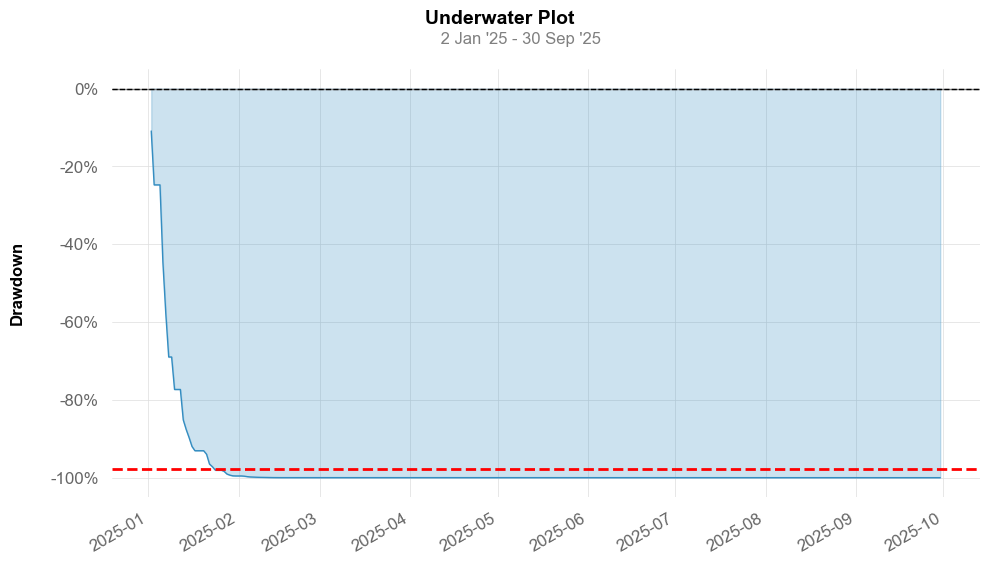

In [41]:
# Max drawdown plot of strategy 3a
summary_GM_daily = (
    dataUSA_GM_GE.resample('D')
    .agg({col: 'sum' for col in dataUSA_GM_GE.columns if col.startswith('pnl_') or col.startswith('ntrans')})
)
returns_strategy = summary_GM_daily['pnl_net3a_mom_pct'].dropna()

qs.plots.drawdown(returns_strategy, figsize=(10, 6))